In [3]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import re
import sys
sys.path.append('..')
from src.dl.viz_dl import *

In [4]:
root = Path("../results/custom_vs_orig")

# Load & parse the Jsons
def collect_results(dirpath: Path):
    files = sorted(dirpath.glob("*.json"))
    suf_re = re.compile(r'_(custom|orig)_split$', re.IGNORECASE)

    rows = []
    for p in files:
        base = p.stem
        m = suf_re.search(base)
        if not m:
            print(f"[skip] {p.name}: unknown suffix"); 
            continue
        model = base[:m.start()]
        split = m.group(1).capitalize()  # Custom / Orig
        with open(p, "r") as f:
            d = json.load(f)
        metr = d.get("test_metrics", d)
        rows.append({
            "Model": model,
            "Split": split,
            "Valence R²": float(metr["r2_v"]),
            "Arousal R²": float(metr["r2_a"]),
            "Valence RMSE": float(metr["rmse_v"]),
            "Arousal RMSE": float(metr["rmse_a"]),
        })
    if not rows:
        raise RuntimeError("No JSONs parsed. Check filenames/suffixes.")
    return pd.DataFrame(rows)

df = collect_results(root)

In [5]:
def pivot_metric(df, metric_col):
    piv = df.pivot(index="Model", columns="Split", values=metric_col)
    # ensure both columns present if possible
    cols = [c for c in ["Orig","Custom"] if c in piv.columns]
    piv = piv[cols]
    # sort by Orig if present, else by Custom
    sort_col = "Orig" if "Orig" in piv.columns else cols[0]
    return piv.sort_values(by=sort_col, ascending=False)

pv_v = pivot_metric(df, "Valence R²")
pv_a = pivot_metric(df, "Arousal R²")

In [6]:
def plot_barh_pair(piv, title, savepath=None):
    h = max(4, 0.35 * len(piv))  # dynamic height
    ax = piv.plot(kind="barh", figsize=(10, h), width=0.82)
    ax.set_xlabel("R²")
    ax.set_ylabel("Model")
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    # annotate bars
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", padding=3, fontsize=8)
    plt.tight_layout()
    if savepath:
        Path(savepath).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savepath, bbox_inches="tight")
        print(f"saved: {savepath}")
    plt.show()

saved: ../results/mert/plots/custom_vs_orig_r2_valence.png


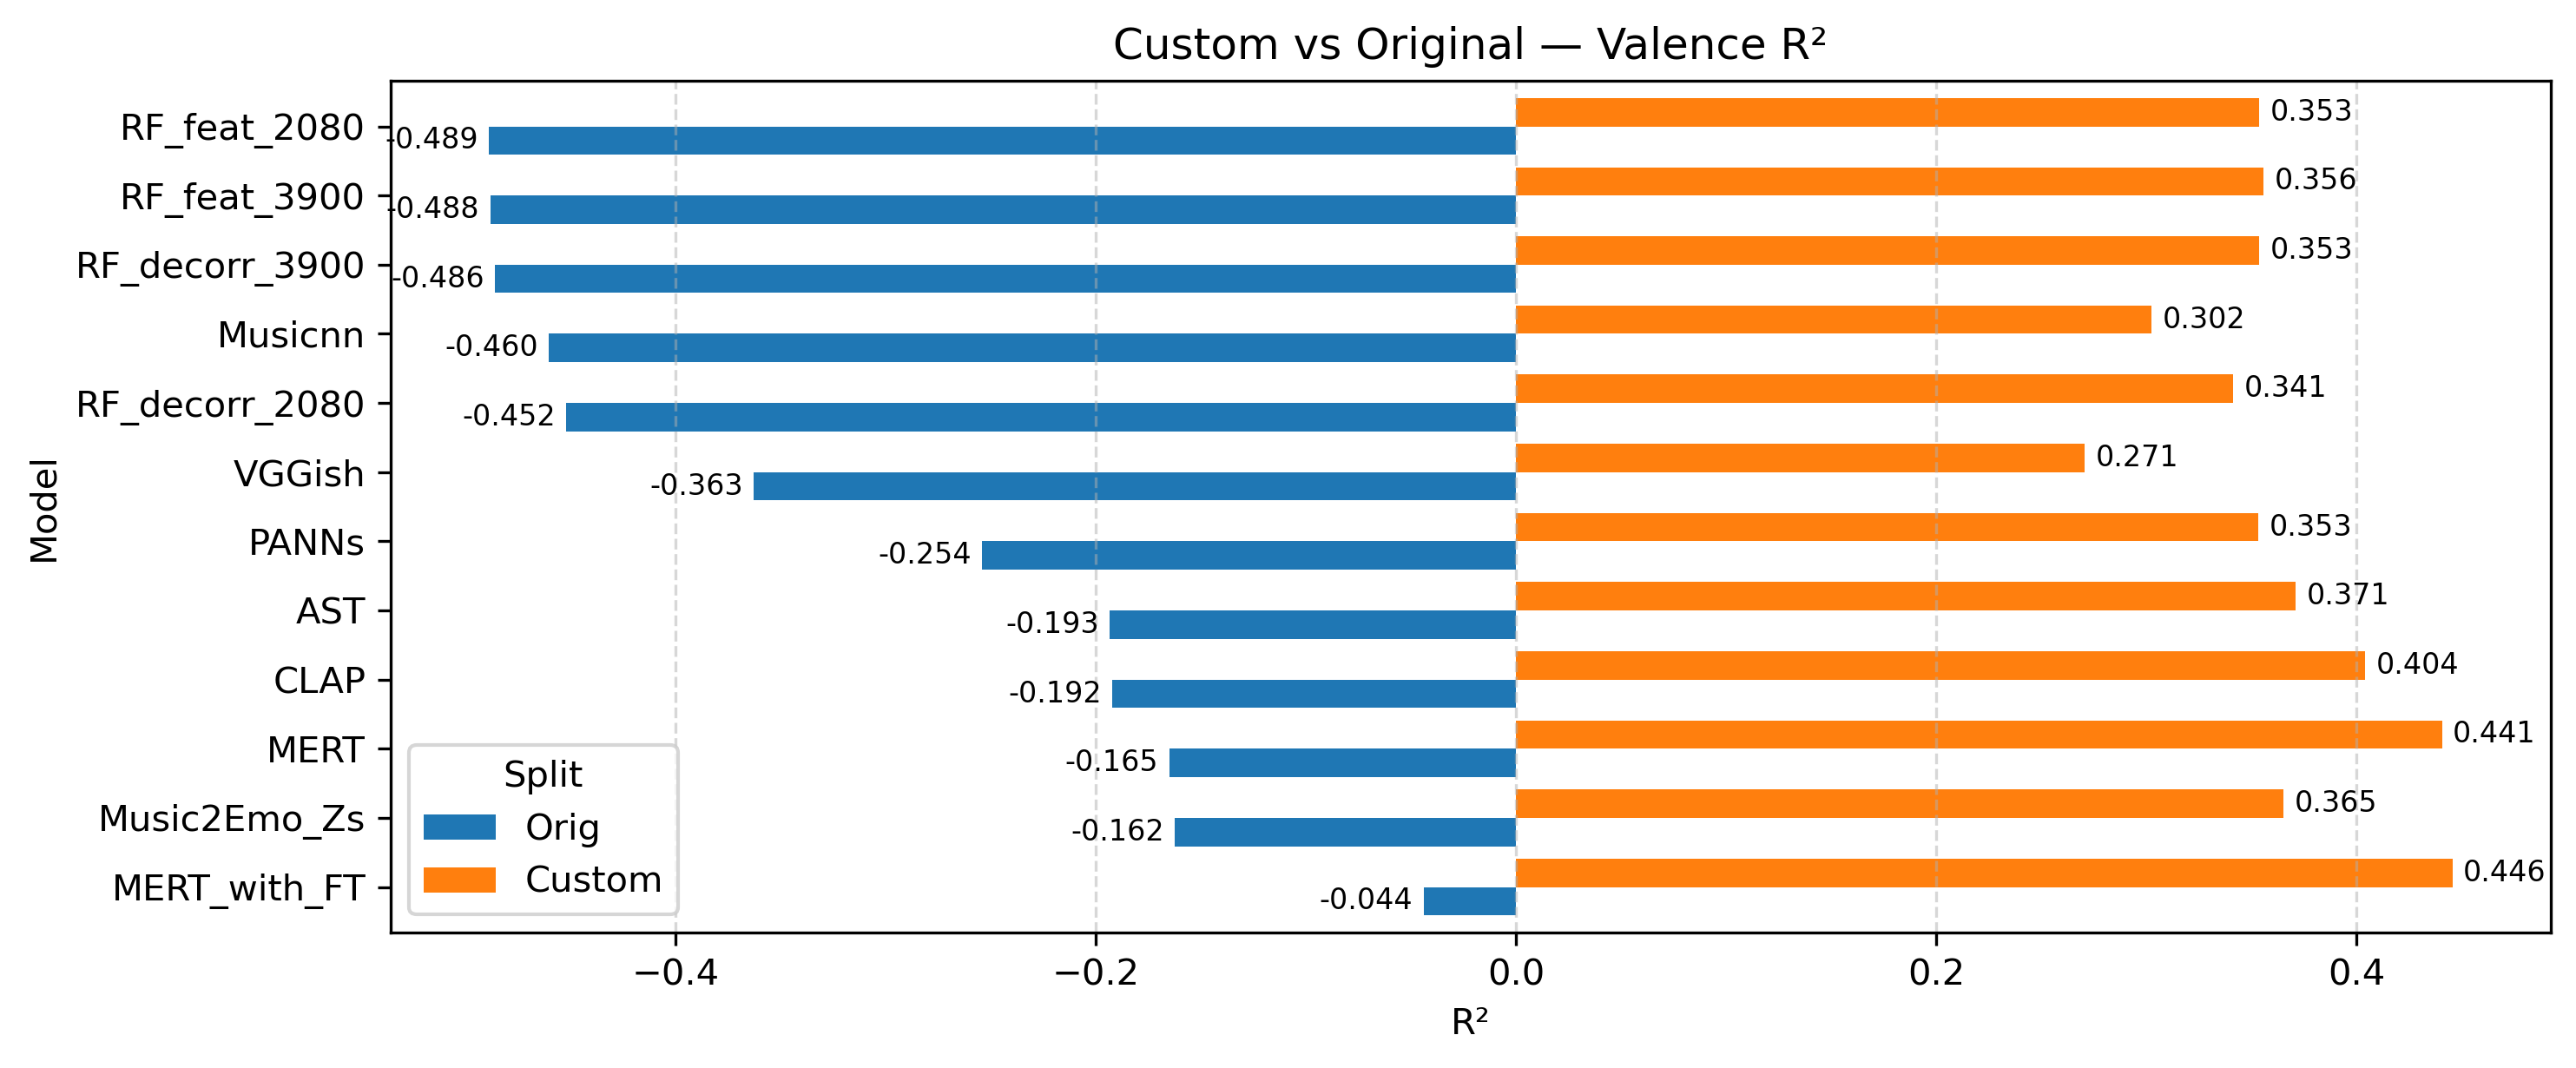

saved: ../results/mert/plots/custom_vs_orig_r2_arousal.png


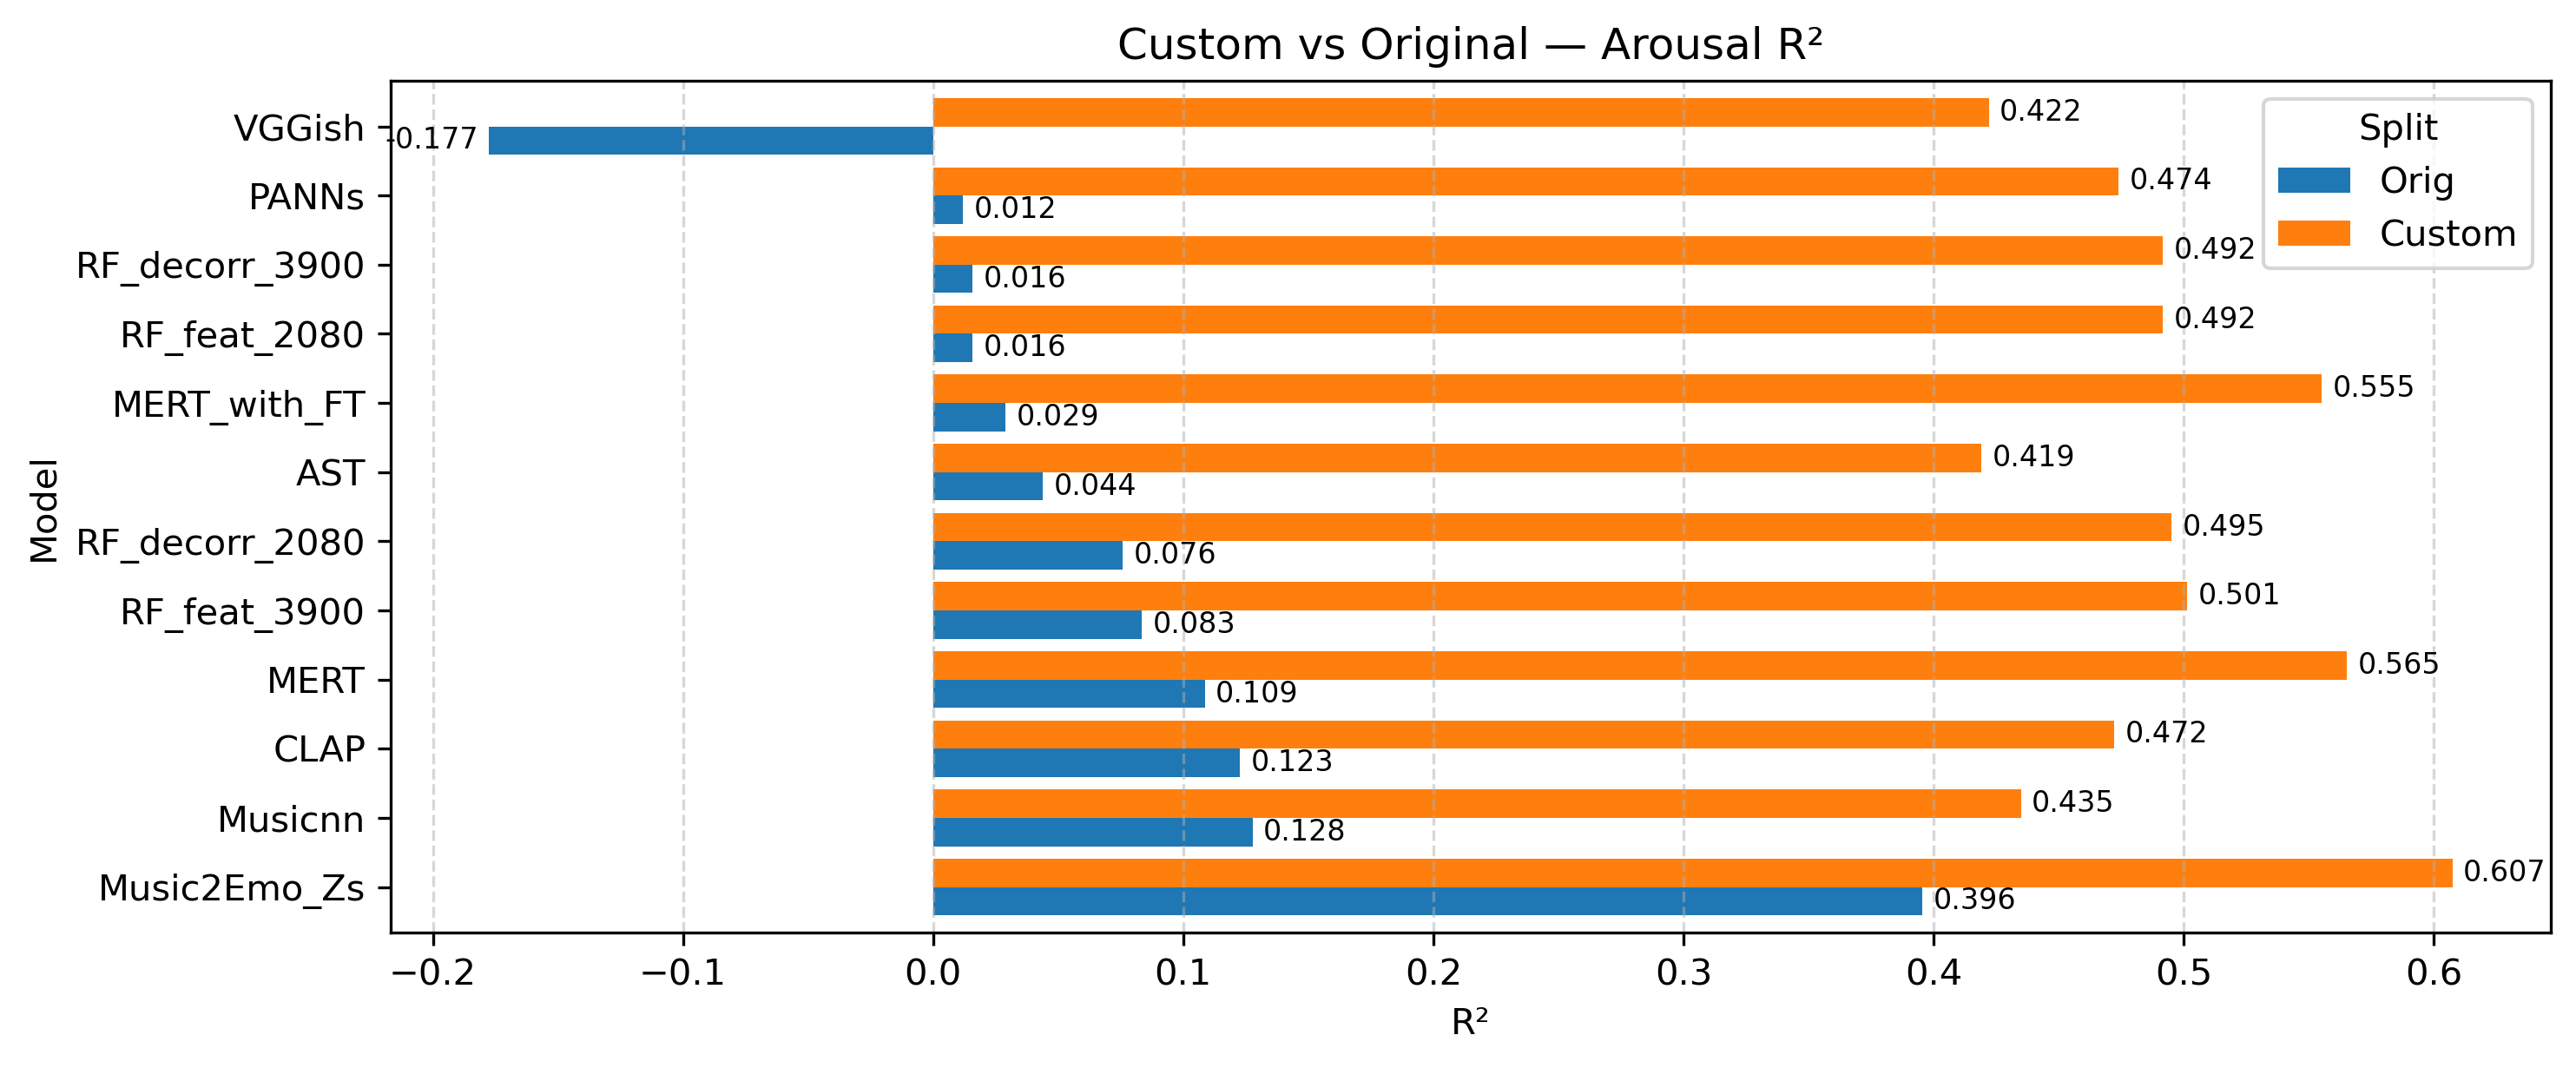

In [7]:
plot_barh_pair(pv_v, "Custom vs Original — Valence R²",
               "../results/mert/plots/custom_vs_orig_r2_valence.png")
plot_barh_pair(pv_a, "Custom vs Original — Arousal R²",
               "../results/mert/plots/custom_vs_orig_r2_arousal.png")

### comparison across models (custom split only)

In [49]:
root = Path("../results/final_test_metrics")
outdir = root / "plots"
outdir.mkdir(parents=True, exist_ok=True)

rows = []
for p in sorted(root.glob("*.json")):
    base = p.stem
    model = base.removesuffix("_Custom_split")
    category = "Classic ML (RF)" if model.startswith("KNN_") or model.startswith('GBR_') else "DL"
    with open(p, "r") as f:
        d = json.load(f)
    m = d.get("test_metrics", d)
    rows.append({
        "Model": model,
        "Category": category,
        "Valence R²": float(m["r2_v"]),
        "Arousal R²": float(m["r2_a"]),
        "Valence RMSE": float(m["rmse_v"]),
        "Arousal RMSE": float(m["rmse_a"]),
    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} models")

Loaded 16 models


saved: ../results/final_test_metrics/plots/custom_only_r2_valence.png


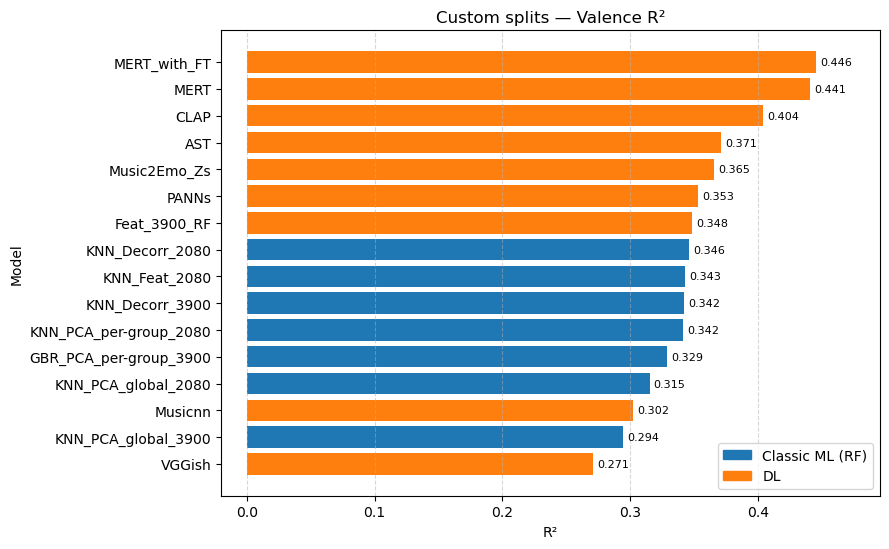

In [50]:
from src.viz import plot_custom_barh
plot_custom_barh(df, "Valence R²", "Custom splits — Valence R²", outdir / "custom_only_r2_valence.png")

saved: ../results/final_test_metrics/plots/custom_only_r2_arousalll.png


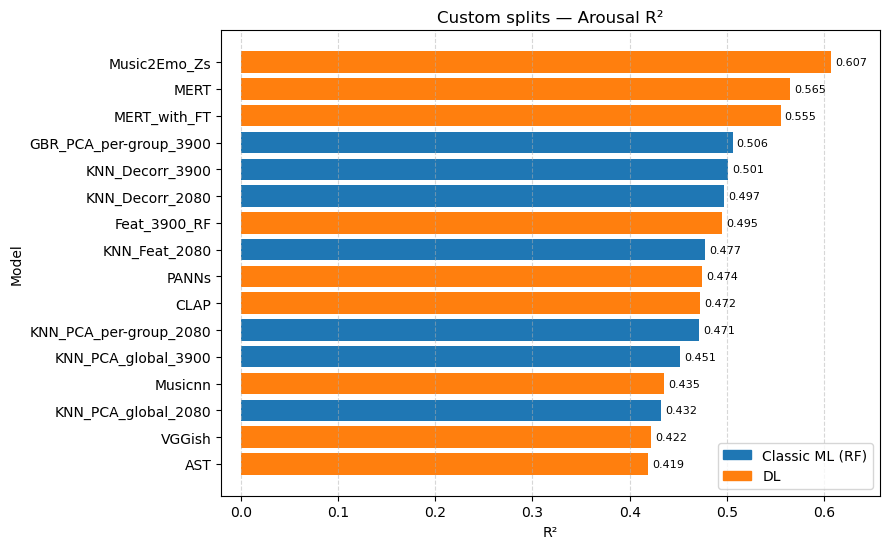

In [51]:
plot_custom_barh(df, "Arousal R²", "Custom splits — Arousal R²", outdir / "custom_only_r2_arousalll.png")

saved: ../results/final_test_metrics/plots/custom_only_r2_arousal.png


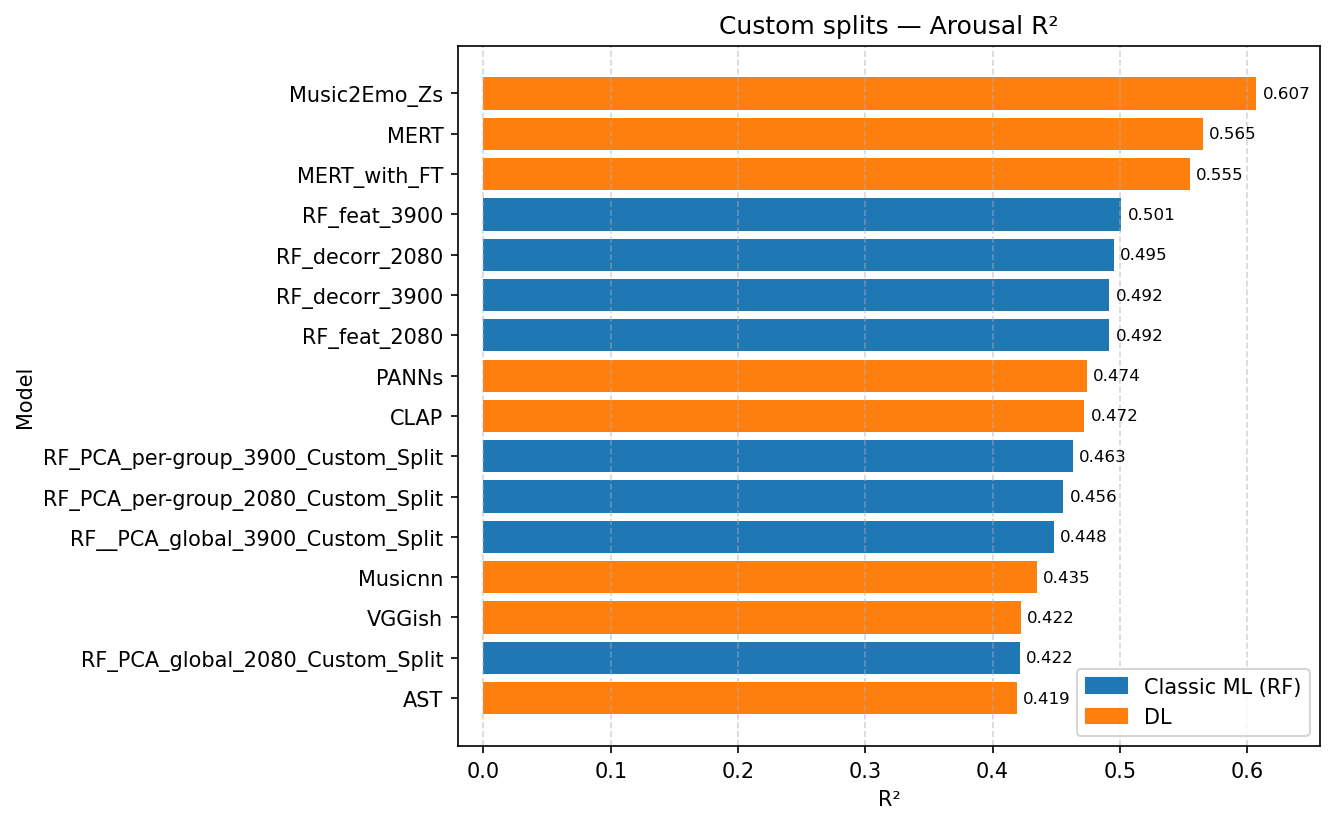

In [22]:
plot_custom_barh(df, "Arousal R²", "Custom splits — Arousal R²", outdir / "custom_only_r2_arousal.png")

### V-A space analysis

In [4]:
import json
from pathlib import Path
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from matplotlib import pyplot as plt
import sys
sys.path.append('..')
from src.viz import plot_bin_accuracy

In [5]:
def knn_predict(dataset_name, params):
    base_dir = Path(f"../data/processed/derived/{dataset_name}")
    
    # Load data
    X_train = pd.read_parquet(base_dir / "custom_split/X_train_scaled_custom.parquet")
    X_val = pd.read_parquet(base_dir / "custom_split/X_val_scaled_custom.parquet")
    X_test = pd.read_parquet(base_dir / "custom_split/X_test_scaled_custom.parquet")
    
    y_train_v = pd.read_csv(base_dir / "custom_split/y_valence_train_custom.csv", index_col=0).iloc[:, 0]
    y_val_v = pd.read_csv(base_dir / "custom_split/y_valence_val_custom.csv", index_col=0).iloc[:, 0]
    y_test_v = pd.read_csv(base_dir / "custom_split/y_valence_test_custom.csv", index_col=0).iloc[:, 0]
    
    y_train_a = pd.read_csv(base_dir / "custom_split/y_arousal_train_custom.csv", index_col=0).iloc[:, 0]
    y_val_a = pd.read_csv(base_dir / "custom_split/y_arousal_val_custom.csv", index_col=0).iloc[:, 0]
    y_test_a = pd.read_csv(base_dir / "custom_split/y_arousal_test_custom.csv", index_col=0).iloc[:, 0]
    
    # Align test indices
    common = X_test.index.intersection(y_test_v.index).intersection(y_test_a.index)
    X_test = X_test.loc[common]
    y_test_v = y_test_v.loc[common]
    y_test_a = y_test_a.loc[common]
    
    # Train on combined train+val
    X_tv = pd.concat([X_train, X_val])
    y_tv_v = pd.concat([y_train_v, y_val_v])
    y_tv_a = pd.concat([y_train_a, y_val_a])
    
    # Train models
    model_v = KNeighborsRegressor(**params)
    model_a = KNeighborsRegressor(**params)
    model_v.fit(X_tv, y_tv_v)
    model_a.fit(X_tv, y_tv_a)
    
    # Get predictions
    pred_v = model_v.predict(X_test)
    pred_a = model_a.predict(X_test)
    
    return pred_v, pred_a, y_test_v.values, y_test_a.values

In [6]:
def plot_va_scatter(pred_v, pred_a, true_v, true_a, title="Model"):
    """Plot predictions vs ground truth in VA space"""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(true_v, true_a, s=15, alpha=0.4, label="True", color='gray')
    ax.scatter(pred_v, pred_a, s=15, alpha=0.6, label="Predicted", color='blue')
    ax.set_xlabel("Valence")
    ax.set_ylabel("Arousal")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show();

In [7]:
with open("../results/hyperparameters.json", 'r') as f:
    hyperparams = json.load(f)


KNN - feat_2080 Accuracies:
  Valence: 58.7%
  Arousal: 60.6%
  Both correct: 38.3%


{'v_acc': 58.7360594795539,
 'a_acc': 60.594795539033456,
 'both_acc': 38.28996282527881,
 'v_edges': array([2.1, 4.4, 5.4, 7.9]),
 'a_edges': array([2.1       , 4.1       , 5.46666667, 7.5       ])}

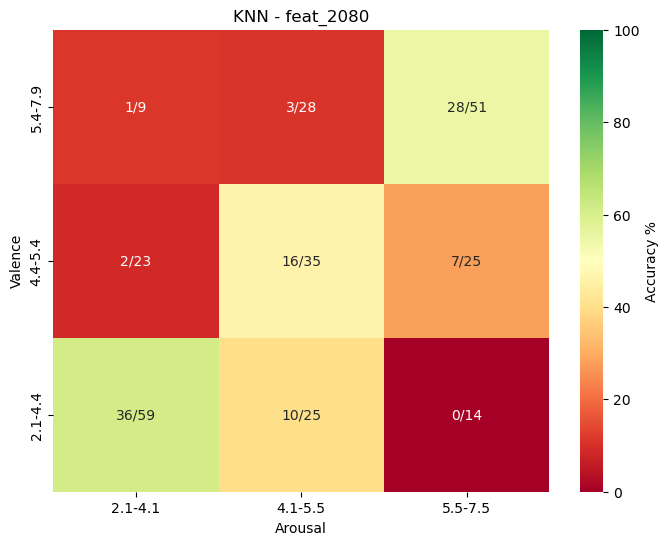

In [8]:
pred_v1, pred_a1, true_v1, true_a1 = knn_predict("exp1_full_2080", hyperparams["feat_2080"]["params"])
plot_bin_accuracy(pred_v1, pred_a1, true_v1, true_a1, n_bins=3, method='percentile', title="KNN - feat_2080")

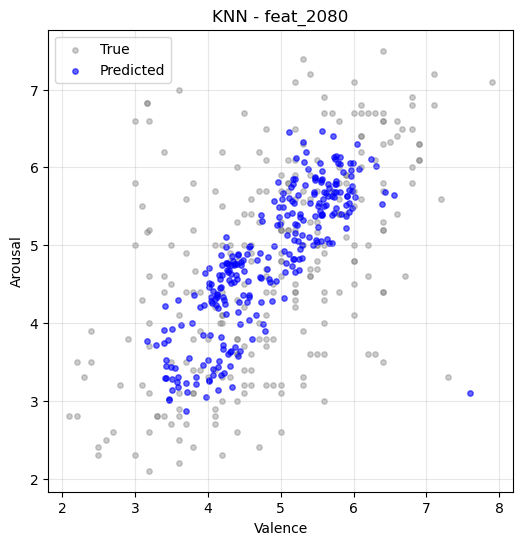

In [9]:
# Plot scatter
plot_va_scatter(pred_v1, pred_a1, true_v1, true_a1, "KNN - feat_2080")


KNN - decorr_3900 Accuracies:
  Valence: 54.3%
  Arousal: 59.9%
  Both correct: 34.9%


{'v_acc': 54.27509293680298,
 'a_acc': 59.85130111524163,
 'both_acc': 34.94423791821561,
 'v_edges': array([2.1, 4.4, 5.4, 7.9]),
 'a_edges': array([2.1       , 4.1       , 5.46666667, 7.5       ])}

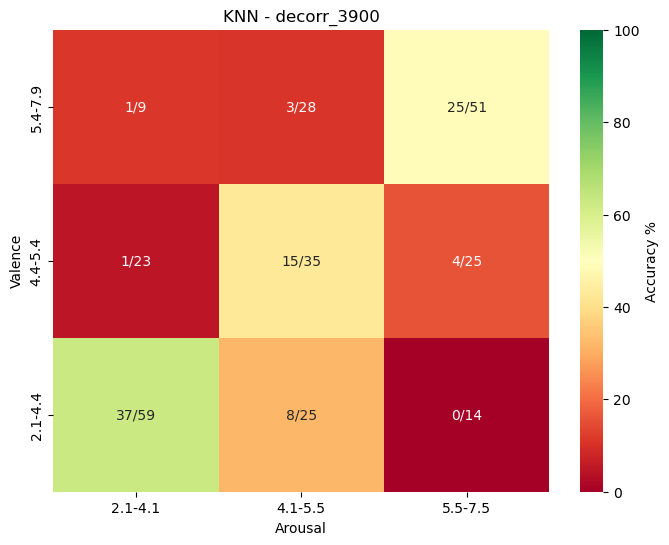

In [10]:
pred_v2, pred_a2, true_v2, true_a2 = knn_predict("exp4_decorrelated_3900", hyperparams["decorr_3900"]["params"])

plot_bin_accuracy(pred_v2, pred_a2, true_v2, true_a2, n_bins=3, method='percentile', title="KNN - decorr_3900")

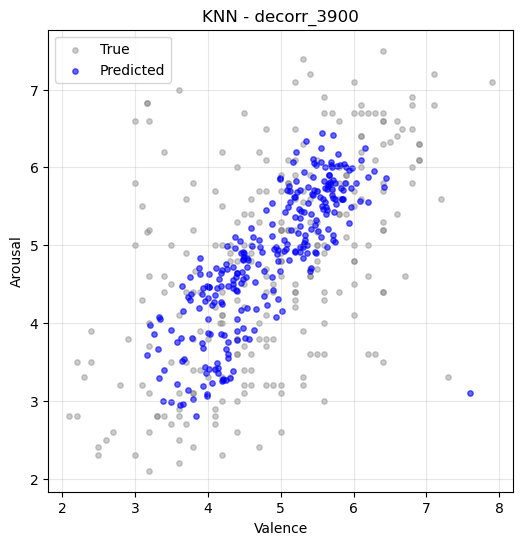

In [11]:
plot_va_scatter(pred_v2, pred_a2, true_v2, true_a2, "KNN - decorr_3900")

In [57]:
from sklearn.ensemble import GradientBoostingRegressor

def gbr_predict(dataset_name, params):
    base_dir = Path(f"../data/processed/derived/{dataset_name}")
    
    X_train = pd.read_parquet(base_dir / "custom_split/X_train_scaled_custom.parquet")
    X_val   = pd.read_parquet(base_dir / "custom_split/X_val_scaled_custom.parquet")
    X_test  = pd.read_parquet(base_dir / "custom_split/X_test_scaled_custom.parquet")
    
    y_train_v = pd.read_csv(base_dir / "custom_split/y_valence_train_custom.csv", index_col=0).iloc[:, 0]
    y_val_v   = pd.read_csv(base_dir / "custom_split/y_valence_val_custom.csv", index_col=0).iloc[:, 0]
    y_test_v  = pd.read_csv(base_dir / "custom_split/y_valence_test_custom.csv", index_col=0).iloc[:, 0]
    
    y_train_a = pd.read_csv(base_dir / "custom_split/y_arousal_train_custom.csv", index_col=0).iloc[:, 0]
    y_val_a   = pd.read_csv(base_dir / "custom_split/y_arousal_val_custom.csv", index_col=0).iloc[:, 0]
    y_test_a  = pd.read_csv(base_dir / "custom_split/y_arousal_test_custom.csv", index_col=0).iloc[:, 0]
    
    common = X_test.index.intersection(y_test_v.index).intersection(y_test_a.index)
    X_test  = X_test.loc[common]
    y_test_v = y_test_v.loc[common]
    y_test_a = y_test_a.loc[common]
    
    # Train on combined train+val
    X_tv   = pd.concat([X_train, X_val])
    y_tv_v = pd.concat([y_train_v, y_val_v])
    y_tv_a = pd.concat([y_train_a, y_val_a])
    
    model_v = GradientBoostingRegressor(random_state=42, **params)
    model_a = GradientBoostingRegressor(random_state=42, **params)
    model_v.fit(X_tv, y_tv_v)
    model_a.fit(X_tv, y_tv_a)
    
    pred_v = model_v.predict(X_test)
    pred_a = model_a.predict(X_test)
    
    return pred_v, pred_a, y_test_v.values, y_test_a.values

In [58]:
pred_v3, pred_a3, true_v3, true_a3 = gbr_predict("exp6_pca_per_group_3900", hyperparams["pca_per_group_3900"]["params"])


GBR - pca_per_group_3900 Accuracies:
  Valence: 53.5%
  Arousal: 60.2%
  Both correct: 34.6%


{'v_acc': 53.531598513011154,
 'a_acc': 60.22304832713755,
 'both_acc': 34.572490706319705,
 'v_edges': array([2.1, 4.4, 5.4, 7.9]),
 'a_edges': array([2.1       , 4.1       , 5.46666667, 7.5       ])}

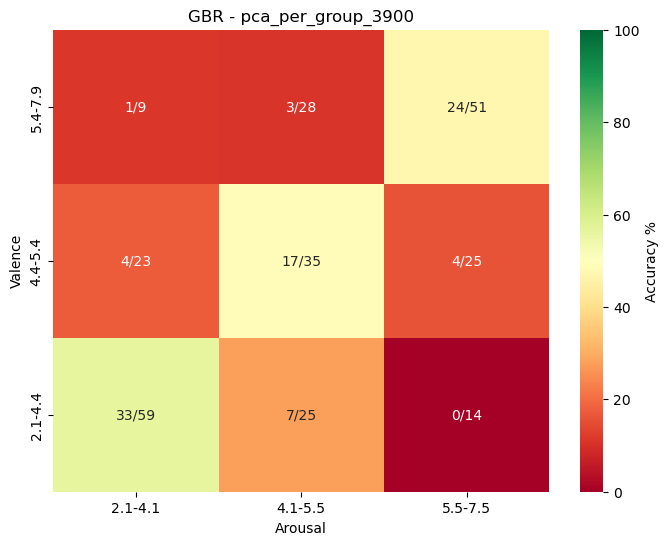

In [59]:
plot_bin_accuracy(pred_v3, pred_a3, true_v3, true_a3, n_bins=3, method='percentile', title="GBR - pca_per_group_3900")

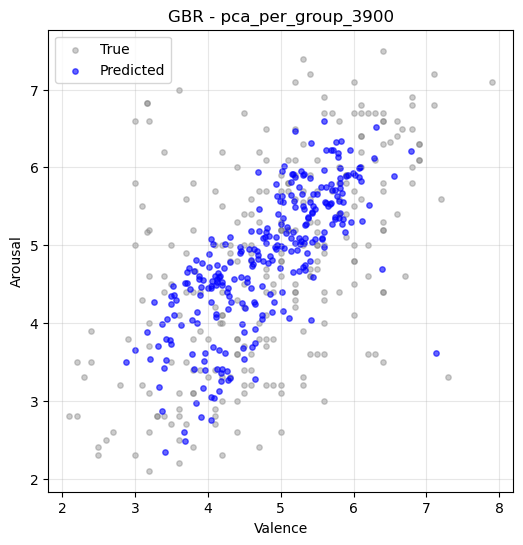

In [60]:
plot_va_scatter(pred_v3, pred_a3, true_v3, true_a3, "GBR - pca_per_group_3900")

In [ ]:
pred_v2, pred_a2, true_v2, true_a2 = knn_predict("exp4_decorrelated_3900", hyperparams["decorr_3900"]["params"])